In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2

2026-06-28 12:50:43.387737: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782651043.614509      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782651043.673587      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782651044.154262      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782651044.154351      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782651044.154354      58 computation_placer.cc:177] computation placer alr

In [3]:
train_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/train"

test_dir = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/test"

In [4]:
IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE = 16

EPOCHS = 10

NUM_CLASSES = 6

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,

    shear_range=0.2,
    zoom_range=0.2,

    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),

    batch_size=16,

    class_mode='categorical',

    subset='training'
)

Found 8723 images belonging to 6 classes.


In [8]:
valid_generator = train_datagen.flow_from_directory(
    train_dir,

    target_size=(128,128),

    batch_size=16,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

Found 2178 images belonging to 6 classes.


In [9]:
test_generator = test_datagen.flow_from_directory(
    test_dir,

    target_size=(128,128),

    batch_size=16,

    class_mode='categorical',

    shuffle=False
)

Found 2698 images belonging to 6 classes.


In [10]:
print(train_generator.class_indices)

{'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


In [12]:
cnn_model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

In [13]:
cnn_model.compile(
    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [14]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,574 (24.86 MB)

 Trainable params: 6,517,574 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

In [20]:
history_cnn = cnn_model.fit(
    train_generator,

    validation_data=valid_generator,

    epochs=10,
)

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 244s 443ms/step - accuracy: 0.5620 - loss: 1.1082 - val_accuracy: 0.7934 - val_loss: 0.6106
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 198s 363ms/step - accuracy: 0.7841 - loss: 0.6025 - val_accuracy: 0.8466 - val_loss: 0.4245
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 201s 361ms/step - accuracy: 0.8313 - loss: 0.4838 - val_accuracy: 0.8806 - val_loss: 0.3483
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 198s 363ms/step - accuracy: 0.8557 - loss: 0.4037 - val_accuracy: 0.8921 - val_loss: 0.2989
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 201s 368ms/step - accuracy: 0.8616 - loss: 0.3807 - val_accuracy: 0.9086 - val_loss: 0.2594
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 198s 363ms/step - accuracy: 0.8802 - loss: 0.3325 - val_accuracy: 0.9151 - val_loss: 0.2238
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 198s 363ms/step - accuracy: 0.8940 - loss: 0.3088 - val_accuracy: 0.9215 - val_loss: 0.2290
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 200s 365ms/step - accuracy: 0.8968 -

In [21]:
cnn_model.evaluate(test_generator)

169/169 ━━━━━━━━━━━━━━━━━━━━ 37s 220ms/step - accuracy: 0.9544 - loss: 0.1278


[0.12781831622123718, 0.9544106721878052]

In [22]:
predictions = cnn_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

169/169 ━━━━━━━━━━━━━━━━━━━━ 22s 132ms/step


In [26]:
cm = confusion_matrix(y_true,y_pred)

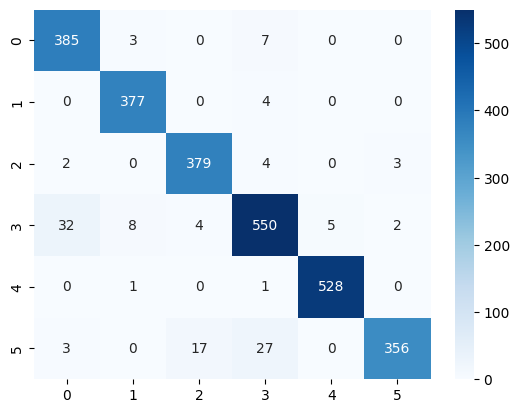

In [27]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.savefig("cnn_confusion_matrix.png")
plt.show()

In [28]:
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

               precision    recall  f1-score   support

  freshapples       0.91      0.97      0.94       395
  freshbanana       0.97      0.99      0.98       381
 freshoranges       0.95      0.98      0.96       388
 rottenapples       0.93      0.92      0.92       601
 rottenbanana       0.99      1.00      0.99       530
rottenoranges       0.99      0.88      0.93       403

     accuracy                           0.95      2698
    macro avg       0.96      0.96      0.96      2698
 weighted avg       0.96      0.95      0.95      2698



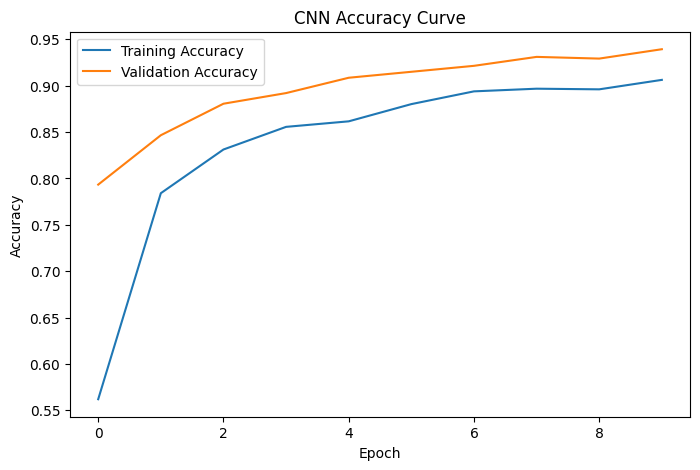

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.savefig('cnn_accuracy_curve.png')

plt.show()

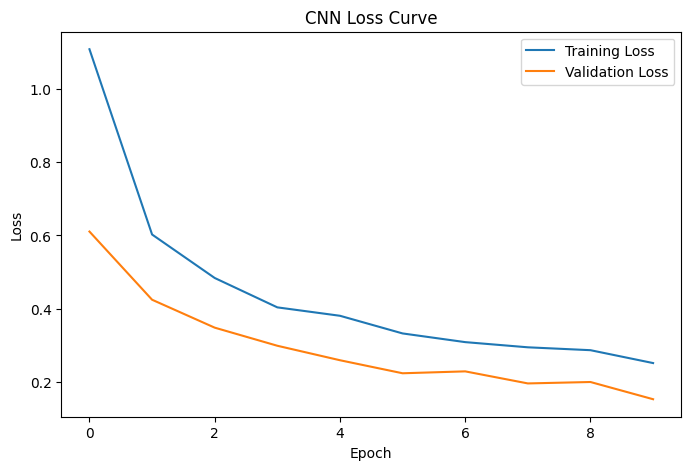

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['loss'],
         label='Training Loss')

plt.plot(history_cnn.history['val_loss'],
         label='Validation Loss')

plt.title('CNN Loss Curve')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.savefig('cnn_loss_curve.png')

plt.show()

In [32]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [33]:
mobilenet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')

])

mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobile = mobilenet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 146s 258ms/step - accuracy: 0.8714 - loss: 0.3569 - val_accuracy: 0.9591 - val_loss: 0.1117
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 139s 254ms/step - accuracy: 0.9327 - loss: 0.1881 - val_accuracy: 0.9679 - val_loss: 0.0888
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 138s 253ms/step - accuracy: 0.9476 - loss: 0.1561 - val_accuracy: 0.9784 - val_loss: 0.0717
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 138s 253ms/step - accuracy: 0.9512 - loss: 0.1379 - val_accuracy: 0.9821 - val_loss: 0.0488
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 138s 253ms/step - accuracy: 0.9575 - loss: 0.1288 - val_accuracy: 0.9890 - val_loss: 0.0403
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 138s 253ms/step - accuracy: 0.9564 - loss: 0.1208 - val_accuracy: 0.9862 - val_loss: 0.0412
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 138s 253ms/step - accuracy: 0.9630 - loss: 0.1089 - val_accuracy: 0.9904 - val_loss: 0.0324
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 139s 254ms/step - accuracy: 0.9603 -

In [37]:
loss_cnn, accuracy_cnn = cnn_model.evaluate(test_generator)

print("Custom CNN Accuracy =", accuracy_cnn)

169/169 ━━━━━━━━━━━━━━━━━━━━ 22s 129ms/step - accuracy: 0.9544 - loss: 0.1278
Custom CNN Accuracy = 0.9544106721878052


In [38]:
loss_mobile, accuracy_mobile = mobilenet_model.evaluate(test_generator)

print("MobileNetV2 Accuracy =", accuracy_mobile)

print()

print("Custom CNN Accuracy =", accuracy_cnn)

print()

print("Difference =", accuracy_mobile - accuracy_cnn)

169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 133ms/step - accuracy: 0.9852 - loss: 0.0355
MobileNetV2 Accuracy = 0.9851741790771484

Custom CNN Accuracy = 0.9544106721878052

Difference = 0.03076350688934326


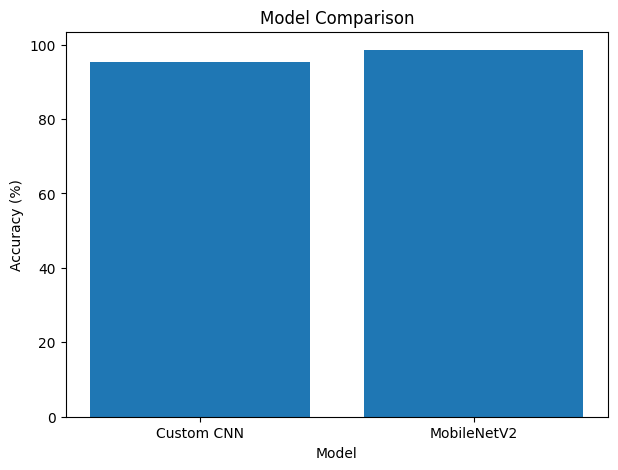

In [39]:
cnn_model.save("cnn_model.h5")

mobilenet_model.save("mobilenet_model.h5")


models = ['Custom CNN', 'MobileNetV2']

accuracies = [
    accuracy_cnn*100,
    accuracy_mobile*100
]

plt.figure(figsize=(7,5))

plt.bar(models, accuracies)

plt.xlabel("Model")

plt.ylabel("Accuracy (%)")

plt.title("Model Comparison")

plt.savefig("model_comparison.png")

plt.show()

In [42]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [43]:
y_true_bin = label_binarize(
    y_true,
    classes=[0,1,2,3,4,5]
)

y_pred_prob = predictions

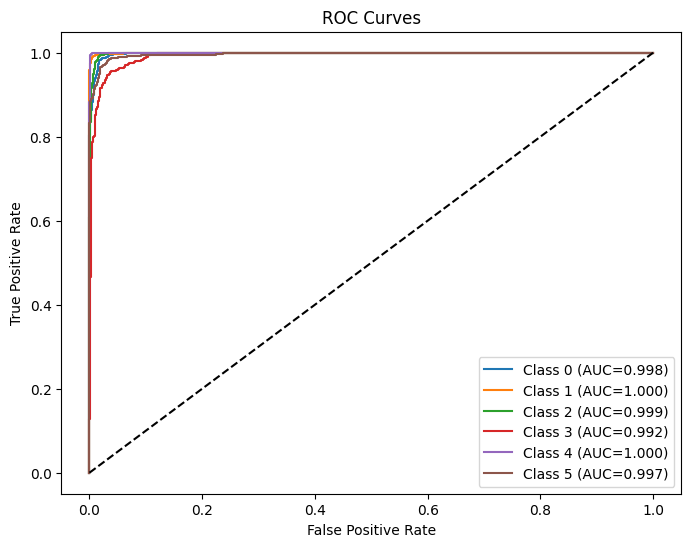

In [44]:
plt.figure(figsize=(8,6))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        y_pred_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} (AUC={roc_auc:.3f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend()

plt.savefig("roc_curve.png")

plt.show()

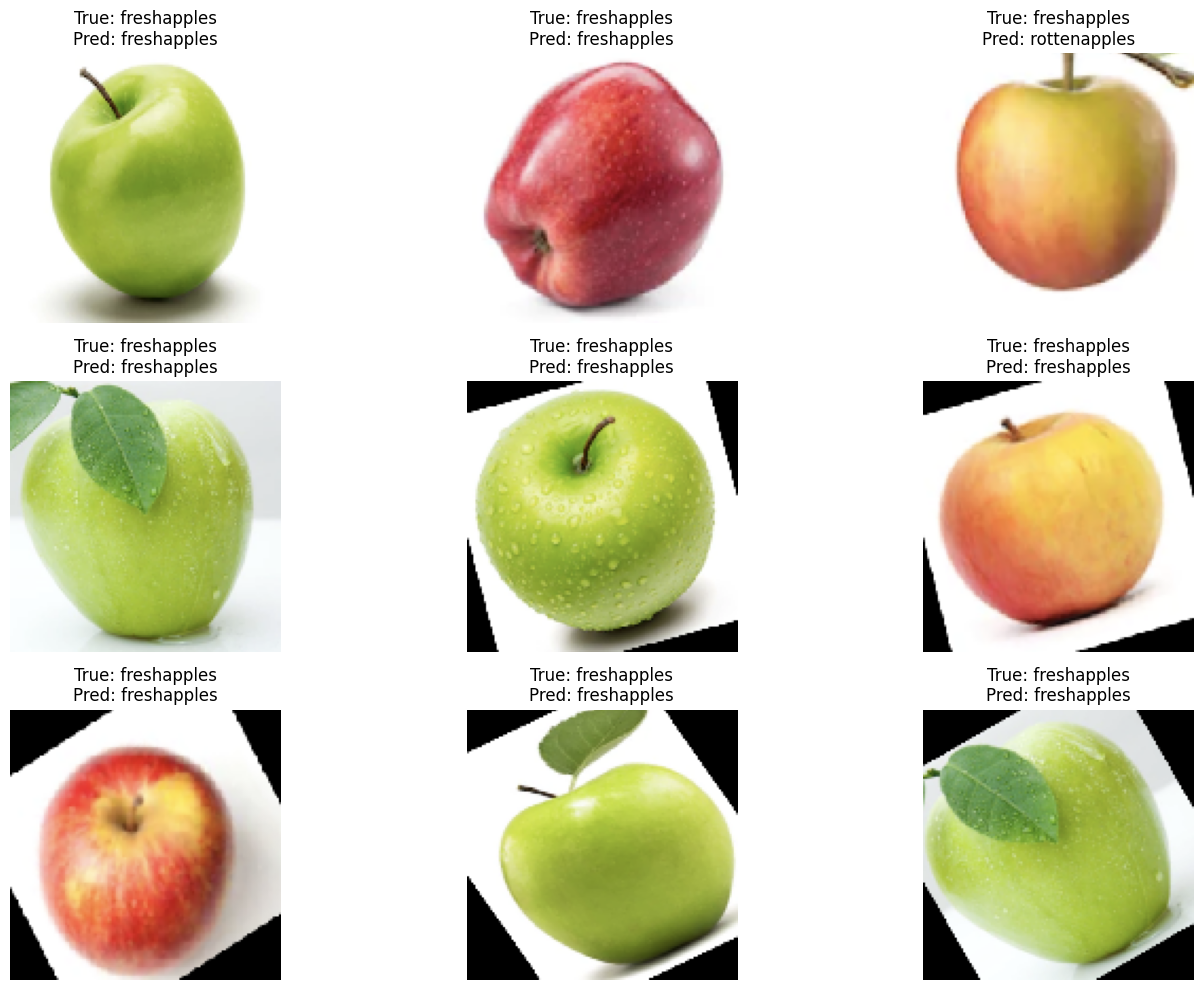

In [45]:
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(15,10))

for i in range(9):

    image, label = test_generator[i]

    img = image[0]

    pred = cnn_model.predict(
        np.expand_dims(img, axis=0),
        verbose=0
    )

    pred_class = class_names[np.argmax(pred)]

    true_class = class_names[np.argmax(label[0])]

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(
        f"True: {true_class}\nPred: {pred_class}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig("sample_predictions.png")

plt.show()

In [46]:
misclassified = np.where(y_true != y_pred)[0]

print("Number of misclassified images:",
      len(misclassified))

Number of misclassified images: 123


ValueError: Asked to retrieve element 214, but the Sequence has length 169

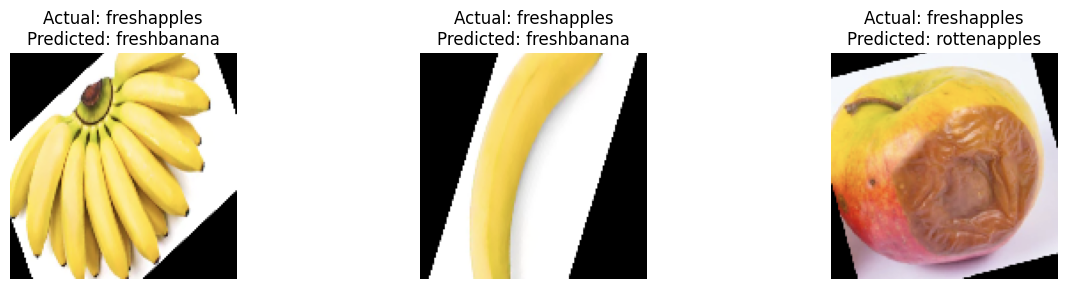

In [47]:
plt.figure(figsize=(15,10))

for i, idx in enumerate(misclassified[:9]):

    img, label = test_generator[idx]

    img = img[0]

    pred = np.argmax(
        cnn_model.predict(
            np.expand_dims(img,0),
            verbose=0
        )
    )

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(
        f"Actual: {class_names[y_true[idx]]}\nPredicted: {class_names[pred]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig("misclassified_images.png")

plt.show()

In [59]:
print("========== FINAL RESULTS ==========")

print()

print(f"Custom CNN Accuracy      : {accuracy_cnn*100:.2f}%")

print(f"MobileNetV2 Accuracy     : {accuracy_mobile*100:.2f}%")

print()

if accuracy_mobile > accuracy_cnn:
    print("MobileNetV2 performed better.")
else:
    print("Custom CNN performed better.")

========== FINAL RESULTS ==========

Custom CNN Accuracy      : 95.44%
MobileNetV2 Accuracy     : 98.52%

MobileNetV2 performed better.
